***
**Signal-Based Capacity and Saturation Analysis for LSA1**
***


**LSA1 Signal and Detector Data Availability at the same Time **

In [10]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# LSA1 COMMON VALID DATE FINDER
# ============================================================
# Purpose:
# - Find dates where BOTH signal-state data and detector data exist
# - Check selected morning/evening windows
# - Suggest usable weekday/weekend scenario days
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA1_f3ab061d-0269-4e8e-b475-f89af4aed051"
)

DETECTOR_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA1"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA1_common_valid_signal_detector_days.csv"
OUT_XLSX = OUT_DIR / "LSA1_common_valid_signal_detector_days.xlsx"

WINDOWS = {
    "morning": ("08:00:00", "09:00:00"),
    "evening": ("16:00:00", "17:00:00"),
}

# Stop-line detectors only
DETECTOR_IDS_TO_CHECK = [7, 9, 11, 13, 23, 26, 27, 28, 30, 40]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_count_from_detector(detector):
    reading = detector.get("reading", {})

    if isinstance(reading, dict):
        count_block = reading.get("count", {})

        if isinstance(count_block, dict):
            return count_block.get("value", 0) or 0

        if isinstance(count_block, (int, float)):
            return count_block

    return 0


def signal_has_values_for_window(date_str, start_str, end_str):
    start_t = pd.to_datetime(start_str).time()
    end_t = pd.to_datetime(end_str).time()

    n_rows = 0

    for json_path in sorted(SIGNAL_DIR.glob(f"{date_str}_*.json")):
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            start_utc = pd.to_datetime(data["start"])

            for value in data.get("values", []):
                timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
                timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

                if (
                    str(timestamp_local.date()) == date_str
                    and start_t <= timestamp_local.time() < end_t
                ):
                    n_rows += 1

        except Exception:
            continue

    return n_rows


def detector_has_counts_for_window(date_str, start_str, end_str):
    json_path = DETECTOR_DIR / f"{date_str}.json"

    if not json_path.exists():
        return 0, 0

    start_t = pd.to_datetime(start_str).time()
    end_t = pd.to_datetime(end_str).time()

    n_measurements = 0
    total_count = 0

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        for timeframe in data.get("timeFrames", []):
            timestamp_str = timeframe.get("timestamp")

            if timestamp_str is None:
                continue

            timestamp = pd.to_datetime(timestamp_str)
            timestamp_local = timestamp.tz_convert("Europe/Berlin") if timestamp.tzinfo else timestamp

            if not (
                str(timestamp_local.date()) == date_str
                and start_t <= timestamp_local.time() < end_t
            ):
                continue

            for detector in timeframe.get("detectors", []):
                det_id = detector.get("id")

                if det_id in DETECTOR_IDS_TO_CHECK:
                    count = extract_count_from_detector(detector)
                    n_measurements += 1
                    total_count += count

    except Exception as e:
        print(f"Could not parse detector file {json_path.name}: {e}")

    return n_measurements, total_count


# ============================================================
# COLLECT ALL POSSIBLE DATES
# ============================================================

signal_dates = set()

for json_path in SIGNAL_DIR.glob("*.json"):
    try:
        # Example: 2026-04-07_0600.json -> 2026-04-07
        signal_dates.add(json_path.name[:10])
    except Exception:
        pass

detector_dates = set()

for json_path in DETECTOR_DIR.glob("*.json"):
    try:
        # Example: 2026-04-07.json -> 2026-04-07
        detector_dates.add(json_path.stem[:10])
    except Exception:
        pass

common_dates = sorted(signal_dates & detector_dates)

print("Signal dates:", len(signal_dates))
print("Detector dates:", len(detector_dates))
print("Common dates:", len(common_dates))

# ============================================================
# CHECK WINDOWS
# ============================================================

rows = []

for date_str in common_dates:
    weekday_name = pd.to_datetime(date_str).day_name()
    day_type = "weekend" if weekday_name in ["Saturday", "Sunday"] else "weekday"

    for window_name, (start_str, end_str) in WINDOWS.items():
        signal_rows = signal_has_values_for_window(date_str, start_str, end_str)
        detector_measurements, detector_total_count = detector_has_counts_for_window(
            date_str,
            start_str,
            end_str
        )

        rows.append({
            "date": date_str,
            "weekday": weekday_name,
            "day_type": day_type,
            "window": window_name,
            "window_start": start_str,
            "window_end": end_str,
            "signal_rows": signal_rows,
            "detector_measurements": detector_measurements,
            "detector_total_count": detector_total_count,
            "usable": (
                signal_rows > 0
                and detector_measurements > 0
                and detector_total_count > 0
            )
        })

df = pd.DataFrame(rows)

df = df.sort_values([
    "usable",
    "day_type",
    "window",
    "date"
], ascending=[False, True, True, True])

df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Common_Valid_Days", index=False)

print("\nSaved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nUsable dates:")
print(df[df["usable"] == True])

print("\nBest candidates by scenario:")
for day_type in ["weekday", "weekend"]:
    for window in ["morning", "evening"]:
        temp = df[
            (df["usable"] == True)
            & (df["day_type"] == day_type)
            & (df["window"] == window)
        ].copy()

        print("\n", day_type, window)
        if temp.empty:
            print("No usable date found.")
        else:
            print(temp.head(10))

Signal dates: 40
Detector dates: 47
Common dates: 40

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_common_valid_signal_detector_days.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_common_valid_signal_detector_days.xlsx

Usable dates:
Empty DataFrame
Columns: [date, weekday, day_type, window, window_start, window_end, signal_rows, detector_measurements, detector_total_count, usable]
Index: []

Best candidates by scenario:

 weekday morning
No usable date found.

 weekday evening
No usable date found.

 weekend morning
No usable date found.

 weekend evening
No usable date found.


In [3]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 1: LSA1 SIGNAL GREEN TIME PARSER
# ============================================================
# Purpose:
# - Read LSA1 signal-state JSON files
# - Filter representative days and one-hour windows
# - Calculate effective green time per movement group
# - Use sgState = 4 as effective green state
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA1_f3ab061d-0269-4e8e-b475-f89af4aed051"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA1_green_time_summary.csv"
OUT_XLSX = OUT_DIR / "LSA1_green_time_summary.xlsx"

GREEN_STATE = 4

MOVEMENT_SIGNAL_MAP = {
    "West_Left":          {"signal_group": "K1", "signal_id": 1},
    "West_StraightRight": {"signal_group": "K2", "signal_id": 2},

    "South_StraightRight": {"signal_group": "K3", "signal_id": 3},

    "East_Right":         {"signal_group": "K6", "signal_id": 6},
    "East_StraightRight": {"signal_group": "K4", "signal_id": 4},
    "East_Left":          {"signal_group": "K5", "signal_id": 5},

    "North_Right":    {"signal_group": "K8", "signal_id": 8},
    "North_Straight": {"signal_group": "K7", "signal_id": 7},
}

SCENARIOS = {
    "weekday_morning": {
        "date": "2026-04-07",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekday_evening": {
        "date": "2026-04-07",
        "start": "16:00:00",
        "end": "17:00:00",
    },
    "weekend_morning": {
        "date": "2026-04-04",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekend_evening": {
        "date": "2026-04-04",
        "start": "16:00:00",
        "end": "17:00:00",
    },
}

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {
                item["id"]: item["sgState"]
                for item in value.get("sigState", [])
            }

            node_info = value.get("nodes", [{}])[0]

            for movement, info in MOVEMENT_SIGNAL_MAP.items():
                signal_id = info["signal_id"]

                if signal_id in sig_states:
                    sg_state = sig_states[signal_id]

                    rows.append({
                        "file": json_path.name,
                        "timestamp_local": timestamp_local,
                        "date": str(timestamp_local.date()),
                        "time": timestamp_local.time(),
                        "movement": movement,
                        "signal_group": info["signal_group"],
                        "signal_id": signal_id,
                        "sg_state": sg_state,
                        "is_green": sg_state == GREEN_STATE,
                        "program": node_info.get("program"),
                        "stage": node_info.get("stage"),
                        "cycCnt": node_info.get("cycCnt"),
                        "stgCnt": node_info.get("stgCnt"),
                        "stgTran": node_info.get("stgTran"),
                    })

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_signal = pd.DataFrame(rows)

print("Parsed signal rows:", len(df_signal))

if df_signal.empty:
    raise ValueError("No signal data parsed. Check SIGNAL_DIR.")

selected_parts = []

for scenario_name, scenario in SCENARIOS.items():
    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    temp = df_signal[
        (df_signal["date"] == scenario["date"]) &
        (df_signal["time"] >= start_t) &
        (df_signal["time"] < end_t)
    ].copy()

    temp["scenario"] = scenario_name
    temp["window_start"] = scenario["start"]
    temp["window_end"] = scenario["end"]

    selected_parts.append(temp)

df_selected_signal = pd.concat(selected_parts, ignore_index=True)

print("Selected signal rows:", len(df_selected_signal))

if df_selected_signal.empty:
    raise ValueError("No signal data found for selected representative scenarios.")

green_summary = (
    df_selected_signal
    .groupby([
        "scenario",
        "date",
        "window_start",
        "window_end",
        "movement",
        "signal_group",
        "signal_id"
    ])
    .agg(
        observed_seconds=("sg_state", "count"),
        green_seconds=("is_green", "sum"),
        cycle_count=("cycCnt", "nunique")
    )
    .reset_index()
)

green_summary["green_minutes"] = green_summary["green_seconds"] / 60
green_summary["green_share_percent"] = green_summary["green_seconds"] / green_summary["observed_seconds"] * 100
green_summary["avg_cycle_time_s"] = green_summary["observed_seconds"] / green_summary["cycle_count"]
green_summary["avg_green_per_cycle_s"] = green_summary["green_seconds"] / green_summary["cycle_count"]

green_summary = green_summary.sort_values(["scenario", "movement"])

green_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

df_selected_signal_excel = df_selected_signal.copy()
df_selected_signal_excel["timestamp_local"] = df_selected_signal_excel["timestamp_local"].astype(str)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    green_summary.to_excel(writer, sheet_name="Green_Time_Summary", index=False)
    df_selected_signal_excel.to_excel(writer, sheet_name="Secondwise_Signal_Data", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nGreen time summary:")
print(green_summary)

Found signal JSON files: 320
Parsed signal rows: 4447232
Selected signal rows: 115216
Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_green_time_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_green_time_summary.xlsx

Green time summary:
           scenario        date window_start window_end             movement  \
0   weekday_evening  2026-04-07     16:00:00   17:00:00            East_Left   
1   weekday_evening  2026-04-07     16:00:00   17:00:00           East_Right   
2   weekday_evening  2026-04-07     16:00:00   17:00:00   East_StraightRight   
3   weekday_evening  2026-04-07     16:00:00   17:00:00          North_Right   
4   weekday_evening  2026-04-07     16:00:00   17:00:00       North_Straight   
5   weekday_evening  2026-04-07     16:00:00   17:00:00  South_StraightRight   
6   weekday_evening  2026-04-07     16:00:00   17:00:00            West_Left   
7   weekday_evening  20

*********
**LSA1 Green share figures**


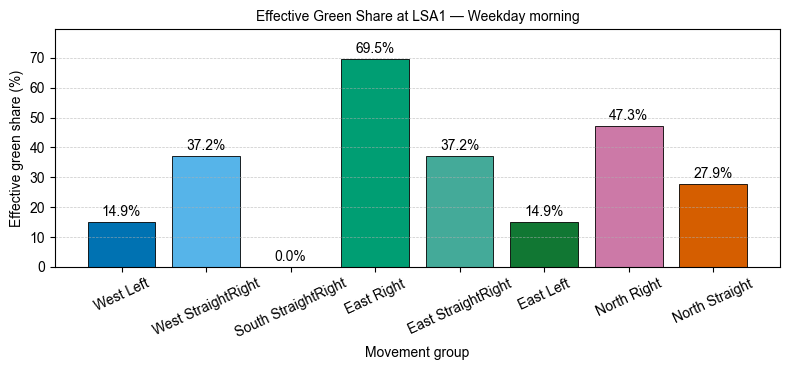

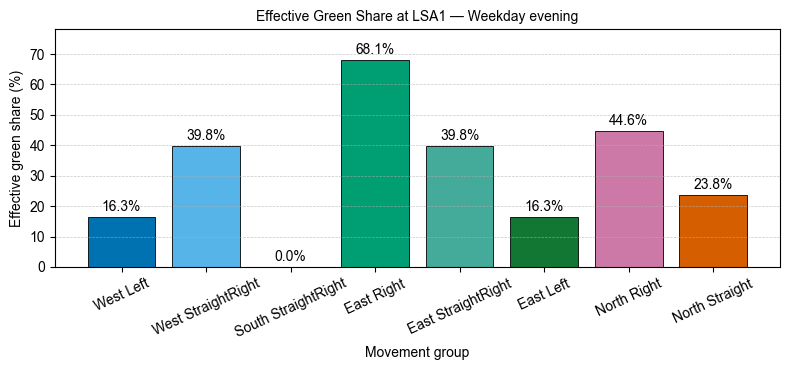

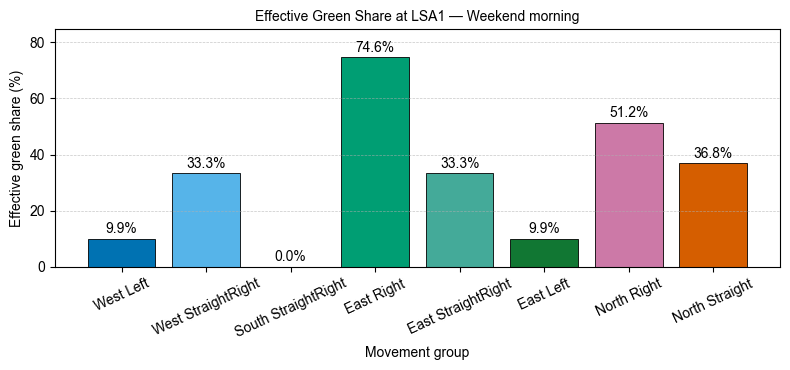

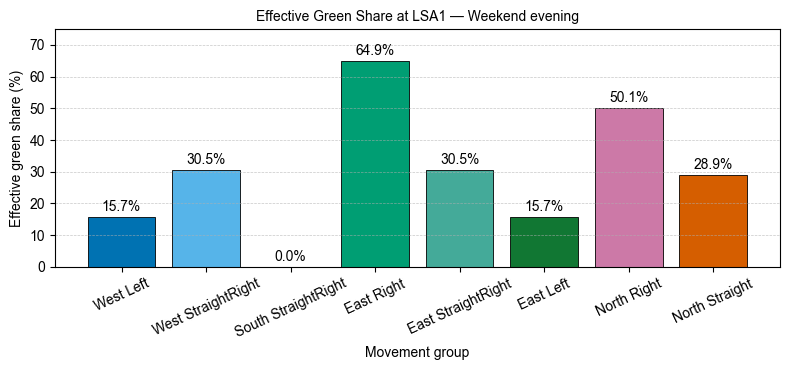

Saved green share figures in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 1B: LSA1 GREEN SHARE FIGURES
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)

IN_CSV = BASE_DIR / "LSA1_green_time_summary.csv"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MOVEMENT_ORDER = [
    "West_Left",
    "West_StraightRight",
    "South_StraightRight",
    "East_Right",
    "East_StraightRight",
    "East_Left",
    "North_Right",
    "North_Straight",
]

SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

MOVEMENT_COLORS = {
    "West_Left": "#0072B2",
    "West_StraightRight": "#56B4E9",
    "South_StraightRight": "#E69F00",
    "East_Right": "#009E73",
    "East_StraightRight": "#44AA99",
    "East_Left": "#117733",
    "North_Right": "#CC79A7",
    "North_Straight": "#D55E00",
}

def clean_label(x):
    return str(x).replace("_", " ")

df = pd.read_csv(IN_CSV)

df["movement"] = pd.Categorical(df["movement"], categories=MOVEMENT_ORDER, ordered=True)
df["scenario"] = pd.Categorical(df["scenario"], categories=SCENARIO_ORDER, ordered=True)

df = df.sort_values(["scenario", "movement"])

for scenario in SCENARIO_ORDER:
    temp = df[df["scenario"] == scenario].sort_values("movement")
    label = SCENARIO_LABELS[scenario]

    fig, ax = plt.subplots(figsize=(8.0, 3.8))

    bars = ax.bar(
        [clean_label(x) for x in temp["movement"].astype(str)],
        temp["green_share_percent"],
        color=[MOVEMENT_COLORS[x] for x in temp["movement"].astype(str)],
        edgecolor="black",
        linewidth=0.6
    )

    ax.set_title(f"Effective Green Share at LSA1 — {label}")
    ax.set_xlabel("Movement group")
    ax.set_ylabel("Effective green share (%)")
    ax.set_ylim(0, max(70, temp["green_share_percent"].max() + 10))
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.tick_params(axis="x", rotation=25)

    for bar, value in zip(bars, temp["green_share_percent"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA1_green_share_{scenario}.png"
    out_svg = OUT_DIR / f"LSA1_green_share_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

print("Saved green share figures in:")
print(OUT_DIR)

**************
**LSA1 Detector Demand Parser**

In [9]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 2: LSA1 DETECTOR DEMAND PARSER
# ============================================================
# Purpose:
# - Read LSA1 detector JSON files
# - Aggregate stop-line detector counts by movement group
# - Exclude upstream detectors 14, 24 and defective detector 25
# ============================================================

DETECTOR_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA1"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA1_detector_demand_summary.csv"
OUT_XLSX = OUT_DIR / "LSA1_detector_demand_summary.xlsx"

MOVEMENT_DETECTOR_MAP = {
    "West_Left":          [7],
    "West_StraightRight": [9],

    "South_StraightRight": [11],

    "East_Right":         [27],
    "East_StraightRight": [13, 23],
    "East_Left":          [26],

    "North_Right":    [40],
    "North_Straight": [28, 30],
}

SCENARIOS = {
    "weekday_morning": {"date": "2026-03-10", "file": "2026-03-10.json", "start": "08:00:00", "end": "09:00:00"},
    "weekday_evening": {"date": "2026-03-23", "file": "2026-03-23.json", "start": "16:00:00", "end": "17:00:00"},
    "weekend_morning": {"date": "2026-03-14", "file": "2026-03-14.json", "start": "08:00:00", "end": "09:00:00"},
    "weekend_evening": {"date": "2026-03-22", "file": "2026-03-22.json", "start": "16:00:00", "end": "17:00:00"},
}

def extract_count_from_detector(detector):
    reading = detector.get("reading", {})

    if isinstance(reading, dict):
        count_block = reading.get("count", {})

        if isinstance(count_block, dict):
            return count_block.get("value", 0) or 0

        if isinstance(count_block, (int, float)):
            return count_block

    return 0

detail_rows = []
summary_rows = []

for scenario_name, scenario in SCENARIOS.items():
    json_path = DETECTOR_DIR / scenario["file"]

    if not json_path.exists():
        print(f"Missing detector file: {json_path}")
        continue

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    movement_totals = {m: 0 for m in MOVEMENT_DETECTOR_MAP}
    movement_measurements = {m: 0 for m in MOVEMENT_DETECTOR_MAP}

    for timeframe in data.get("timeFrames", []):
        timestamp_str = timeframe.get("timestamp")

        if timestamp_str is None:
            continue

        try:
            timestamp = pd.to_datetime(timestamp_str)
            timestamp_local = timestamp.tz_convert("Europe/Berlin") if timestamp.tzinfo else timestamp

            date_local = str(timestamp_local.date())
            time_local = timestamp_local.time()

            if not (date_local == scenario["date"] and start_t <= time_local < end_t):
                continue

            for detector in timeframe.get("detectors", []):
                det_id = detector.get("id")

                if det_id is None:
                    continue

                count = extract_count_from_detector(detector)

                for movement, detector_ids in MOVEMENT_DETECTOR_MAP.items():
                    if det_id in detector_ids:
                        movement_totals[movement] += count
                        movement_measurements[movement] += 1

                        detail_rows.append({
                            "scenario": scenario_name,
                            "date": scenario["date"],
                            "window_start": scenario["start"],
                            "window_end": scenario["end"],
                            "timestamp_local": str(timestamp_local),
                            "movement": movement,
                            "detector_id": det_id,
                            "count": count,
                        })

        except Exception as e:
            print(f"Skipped timeframe due to error: {e}")

    for movement, detector_ids in MOVEMENT_DETECTOR_MAP.items():
        summary_rows.append({
            "scenario": scenario_name,
            "date": scenario["date"],
            "window_start": scenario["start"],
            "window_end": scenario["end"],
            "movement": movement,
            "detector_ids": "+".join(str(x) for x in detector_ids),
            "demand_veh_per_hour": movement_totals[movement],
            "n_detector_measurements": movement_measurements[movement],
        })

demand_summary = pd.DataFrame(summary_rows)
detector_detail = pd.DataFrame(detail_rows)

if demand_summary.empty:
    raise ValueError("No detector demand data found.")

demand_summary = demand_summary.sort_values(["scenario", "movement"])

demand_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    demand_summary.to_excel(writer, sheet_name="Detector_Demand_Summary", index=False)
    detector_detail.to_excel(writer, sheet_name="Detector_Detail", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nDetector demand summary:")
print(demand_summary)

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_detector_demand_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_detector_demand_summary.xlsx

Detector demand summary:
           scenario        date window_start window_end             movement  \
13  weekday_evening  2026-03-23     16:00:00   17:00:00            East_Left   
11  weekday_evening  2026-03-23     16:00:00   17:00:00           East_Right   
12  weekday_evening  2026-03-23     16:00:00   17:00:00   East_StraightRight   
14  weekday_evening  2026-03-23     16:00:00   17:00:00          North_Right   
15  weekday_evening  2026-03-23     16:00:00   17:00:00       North_Straight   
10  weekday_evening  2026-03-23     16:00:00   17:00:00  South_StraightRight   
8   weekday_evening  2026-03-23     16:00:00   17:00:00            West_Left   
9   weekday_evening  2026-03-23     16:00:00   17:00:00   West_StraightRight   
5   weekday_mo

**SATURATION CALCULATION**

In [6]:
from pathlib import Path
import pandas as pd

# ============================================================
# CODE 3: LSA1 SATURATION CALCULATION
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)

GREEN_FILE = BASE_DIR / "LSA1_green_time_summary.csv"
DEMAND_FILE = BASE_DIR / "LSA1_detector_demand_summary.csv"

OUT_CSV = BASE_DIR / "LSA1_saturation_summary.csv"
OUT_XLSX = BASE_DIR / "LSA1_saturation_summary.xlsx"

green = pd.read_csv(GREEN_FILE)
demand = pd.read_csv(DEMAND_FILE)

df = pd.merge(
    green,
    demand,
    on=["scenario", "date", "window_start", "window_end", "movement"],
    how="inner"
)

df["capacity_veh_per_hour"] = df["green_seconds"] / 2
df["saturation"] = df["demand_veh_per_hour"] / df["capacity_veh_per_hour"]

df["capacity_veh_per_hour"] = df["capacity_veh_per_hour"].round(1)
df["saturation"] = df["saturation"].round(2)

def classify_saturation(x):
    if x < 0.7:
        return "Low"
    elif x < 0.9:
        return "Moderate"
    elif x <= 1.0:
        return "High"
    else:
        return "Over-saturated"

df["saturation_level"] = df["saturation"].apply(classify_saturation)

df = df.sort_values(["scenario", "movement"])

df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Saturation_Summary", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nFinal saturation results:")
print(df)

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_saturation_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_saturation_summary.xlsx

Final saturation results:
Empty DataFrame
Columns: [scenario, date, window_start, window_end, movement, signal_group, signal_id, observed_seconds, green_seconds, cycle_count, green_minutes, green_share_percent, avg_cycle_time_s, avg_green_per_cycle_s, detector_ids, demand_veh_per_hour, n_detector_measurements, capacity_veh_per_hour, saturation, saturation_level]
Index: []


**For LSA1, the saturation analysis could not be performed because no common time window with both valid signal-state data and detector count data was available. Although signal-state files and detector files existed for overlapping dates, the selected morning and evening windows did not contain usable data in both sources simultaneously. Therefore, LSA1 was included in the signal program derivation and SUMO implementation, but excluded from the saturation-rate calculation.**